In [2]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Sat Oct 30 12:37:09 2021

@author: alex
"""
%load_ext autoreload
%autoreload 2

import sys
sys.path.append("/home/alex/Documents/Doktorarbeit/PiezoHysteresis/python")

import mh2t #This will be avaiable soon in cfs/share/python
import hdf5_tools as h5
import numpy as np
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
file = "./PrismaHyst_MH.h5ref"

In [4]:
sq1 = mh2t.MH2T(file, multistep = 1)
sq2 = mh2t.MH2T(file, multistep = 2)

In [5]:
sq1.printAllResults()
sq1.elecPotential.time.Info()
Pot1 = sq1.elecPotential.time.val 
Field1 = np.sqrt(sq1.elecFieldIntensity.time.x**2 + sq1.elecFieldIntensity.time.y**2 + sq1.elecFieldIntensity.time.z**2)
Perm1 = sq1.elecElemPermittivity.time.val

Pot2 = sq2.elecPotential.time.val 
Field2 = np.sqrt(sq2.elecFieldIntensity.time.x**2 + sq2.elecFieldIntensity.time.y**2 + sq2.elecFieldIntensity.time.z**2)
Perm2 = sq2.elecElemPermittivity.time.val

['elecElemPermittivity', 'elecFieldIntensity', 'elecPotential']
[Timesteps, Nodes] = [128, 80]


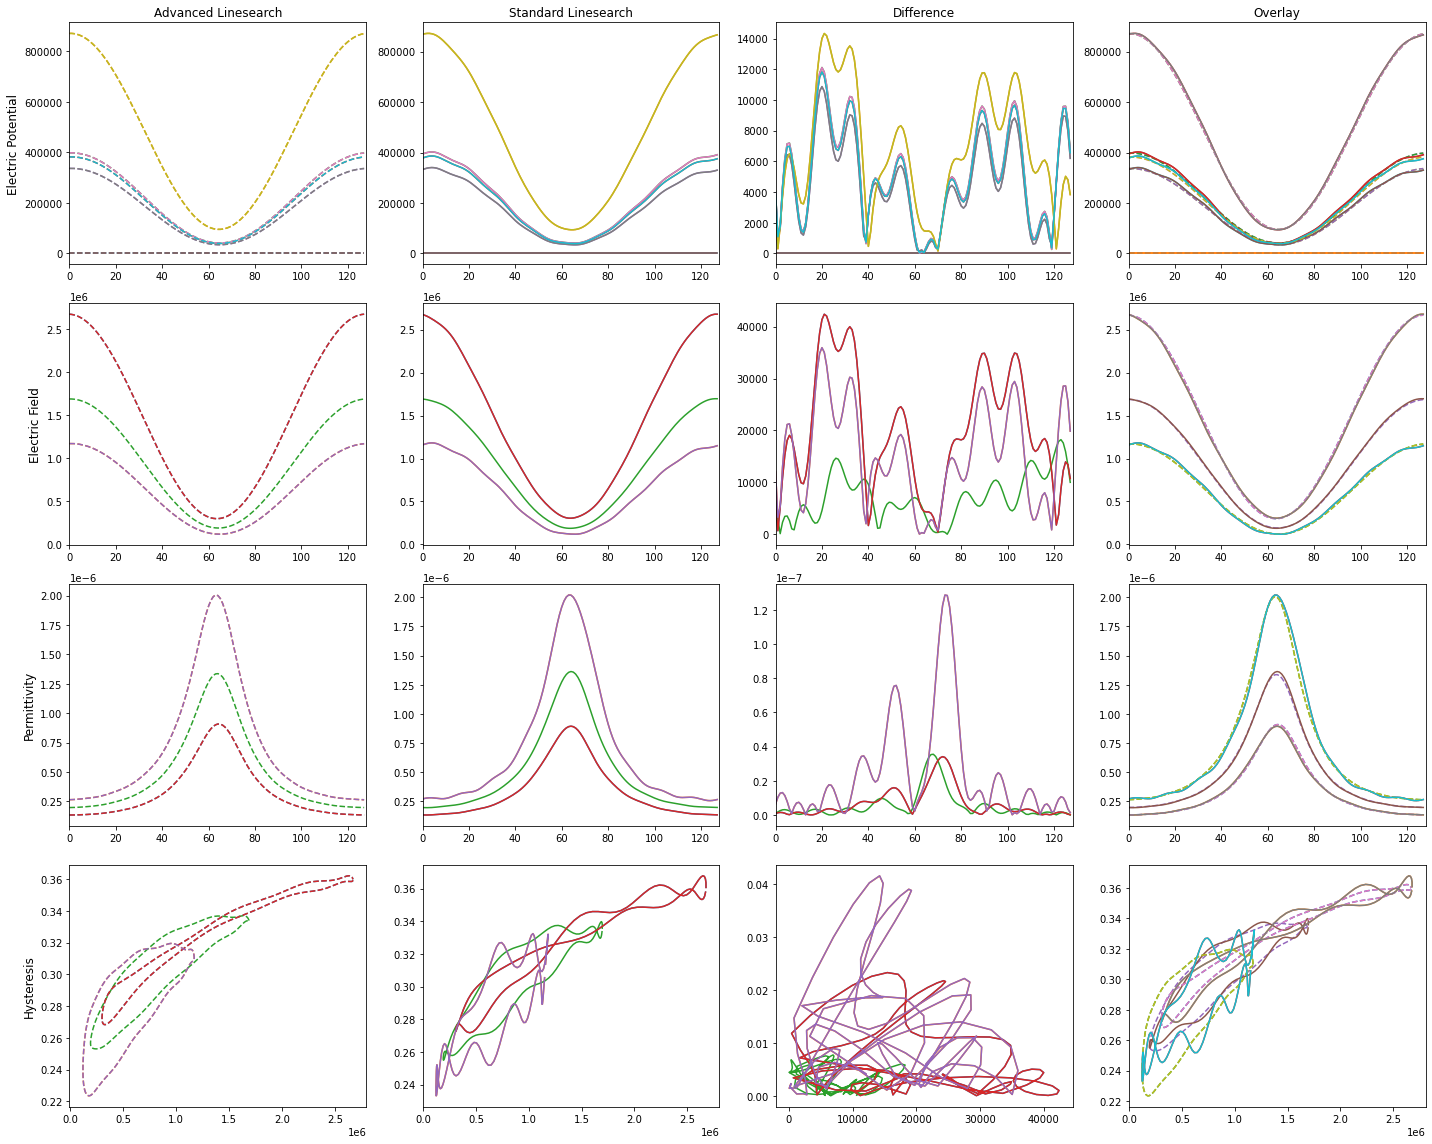

In [6]:
rangeStep= 8
nodeList = [*range(0,Pot1.shape[1], rangeStep)]
elementList = [*range(0,Field1.shape[1], rangeStep)]

fig, ax = plt.subplots(4,4, figsize=(4*5, 4*4))

for node in nodeList:
    ax[0,0].plot(Pot1[:,node] , ls ="--")
    ax[0,1].plot(Pot2[:,node])
    ax[0,2].plot(np.abs(Pot1[:,node]-Pot2[:,node]))
    ax[0,3].plot(Pot1[:,node] , ls ="--")
    ax[0,3].plot(Pot2[:,node])

for elem in elementList:
    ax[1,0].plot(Field1[:,elem], ls ="--")
    ax[2,0].plot(Perm1[:,elem], ls ="--")
    ax[3,0].plot(Field1[:,elem], Perm1[:,elem]*Field1[:,elem], ls ="--")
              
    ax[1,1].plot(Field2[:,elem])
    ax[2,1].plot(Perm2[:,elem])
    ax[3,1].plot(Field2[:,elem], Perm2[:,elem]*Field2[:,elem])
                 
    ax[1,2].plot(np.abs(Field2[:,elem] -Field1[:,elem]))
    ax[2,2].plot(np.abs(Perm2[:,elem] - Perm1[:,elem]))
    ax[3,2].plot(np.abs(Field2[:,elem] - Field1[:,elem]),np.abs( Perm2[:,elem]*Field2[:,elem] - Perm1[:,elem]*Field1[:,elem]))
    
    ax[1,3].plot(Field1[:,elem], ls ="--")
    ax[1,3].plot(Field2[:,elem])

    ax[2,3].plot(Perm1[:,elem], ls ="--")
    ax[2,3].plot(Perm2[:,elem])

    ax[3,3].plot(Field1[:,elem], Perm1[:,elem]*Field1[:,elem], ls ="--")
    ax[3,3].plot(Field2[:,elem], Perm2[:,elem]*Field2[:,elem])

    
cols = ["Advanced Linesearch","Standard Linesearch","Difference","Overlay"]
rows = ['Electric Potential', 'Electric Field', 'Permittivity', 'Hysteresis']

for a, col in zip(ax[0], cols):
    a.set_title(col)

for a, row in zip(ax[:,0], rows):
    a.set_ylabel(row, rotation=90, size='large')

for column in range(4):
    for row in range(3):
        ax[row,column].set_xlim(0,Pot1.shape[0])
    
plt.tight_layout()